# CASE 6: Advanced Stacking Architectures & Pipeline Manipulation
This notebook evaluates 6 incredibly distinct hierarchical classification architectures against our downsampled dataset.


In [6]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

# Stratification & Pipeline Tools
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Base & Meta Algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import accuracy_score, recall_score, f1_score, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports processed natively.")



Imports processed natively.


## 1. Subsampled Global Pool Ingestion
We instantiate `Global_Pool_Subsampled_Train.csv` and set up our 5-Fold Stratified Validation boundaries.


In [7]:
print("Loading heavily imbalanced Subsampled Global Pool...")
df = pd.read_csv("Global_Pool_Subsampled_Train.csv")
X = df.drop(columns=['Label'])
y = df['Label']

# Secure the evaluation metric loop methodology
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



Loading heavily imbalanced Subsampled Global Pool...


## 2. Dynamic Dictionary Mapping of Sub-Cases
[VERBOSE] We cleanly array the parameters requested for `6a` through `6f`.


In [8]:
# Base Instantiations to prevent massive visual clutter
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=50, random_state=42, n_jobs=-1, eval_metric='logloss')
lgb = LGBMClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)
cat = CatBoostClassifier(iterations=50, random_state=42, verbose=False, thread_count=-1)
# svm = LinearSVC(max_iter=1000, random_state=42) # Replaced slow exact RBF-SVC with high-speed Linear projection
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50, random_state=42)

smote_node = SMOTE(random_state=42, k_neighbors=4)

# 6f Specific Base Pipelines (The Anti-Leakage Fold Strategy)
# Wrapping base learners inside the imblearn pipeline.
# When StackingClassifier does cross_val_predict internally for OOF arrays, 
# this ensures SMOTE is strictly bounded to the k-1 inside the folds!
rf_smote = ImbPipeline([('smote', smote_node), ('model', rf)])
xgb_smote = ImbPipeline([('smote', smote_node), ('model', xgb)])
lgb_smote = ImbPipeline([('smote', smote_node), ('model', lgb)])
ada_smote = ImbPipeline([('smote', smote_node), ('model', ada)])

# The core dictionary configuration
ensemble_map = {
    '6a: Baseline (Paper Original)': StackingClassifier(
        estimators=[('dt', dt), ('knn', knn), ('rf', rf)], 
        final_estimator=LogisticRegression(max_iter=1000)
    ),
    '6b: Modern Boosting Baseline': StackingClassifier(
        estimators=[('rf', rf), ('xgb', xgb), ('lgb', lgb)], 
        final_estimator=LogisticRegression(max_iter=1000)
    ),
    '6c: Non-linear Meta-learning': StackingClassifier(
        estimators=[('rf', rf), ('xgb', xgb), ('lgb', lgb)], 
        final_estimator=MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
    ),
    # '6d: High-diversity ensemble': StackingClassifier(
    #     estimators=[('rf', rf), ('xgb', xgb), ('cat', cat), ('svm', svm)], 
    #     final_estimator=LGBMClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)
    # ),
    '6e: Boosting on Boosting': StackingClassifier(
        estimators=[('rf', rf), ('xgb', xgb), ('lgb', lgb), ('ada', ada)], 
        final_estimator=XGBClassifier(n_estimators=50, random_state=42, n_jobs=-1, eval_metric='logloss')
    ),
    '6f: Internal SMOTE inside Folds': StackingClassifier(
        estimators=[('rf_sm', rf_smote), ('xgb_sm', xgb_smote), ('lgb_sm', lgb_smote), ('ada_sm', ada_smote)], 
        final_estimator=LGBMClassifier(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)
    )
}



## 3. The 5-Fold Stratified Architecture Evaluation


In [9]:
results_list = []

print("[VERBOSE] Launching Stacked Evaluations...")
print("==================================================")

for key, model in ensemble_map.items():
    print(f"\nProcessing -> {key}")
    
    # Store metrics for folds
    metrics = {'macro_f1': [], 'weighted_f1': [], 'mcc': [], 'recall': [], 'accuracy': []}
    
    # Executing external Stratified 5-Fold validation loop
    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        print(f"   [Fold {fold+1}/5] computing internal boundaries...", end=' ')
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
        
        # Fit the stacking architecture natively
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        metrics['macro_f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
        metrics['weighted_f1'].append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
        metrics['mcc'].append(matthews_corrcoef(y_test, y_pred))
        metrics['recall'].append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        metrics['accuracy'].append(accuracy_score(y_test, y_pred))
        print("Done!")
        
    avg_results = {
        'Case': key.split(":")[0], 
        'Architecture': key.split(":")[1].strip(),
        'Macro F1': np.mean(metrics['macro_f1']),
        'Weighted F1': np.mean(metrics['weighted_f1']),
        'MCC': np.mean(metrics['mcc']),
        'Recall': np.mean(metrics['recall']),
        'Accuracy': np.mean(metrics['accuracy'])
    }
    
    print(f"  --> Yield MCC: {avg_results['MCC']:.4f} | Macro F1: {avg_results['Macro F1']:.4f}")
    results_list.append(avg_results)
    
df_results = pd.DataFrame(results_list)
print("\n================ STACKING RESULTS METRICS =================\n")
display(df_results)



[VERBOSE] Launching Stacked Evaluations...

Processing -> 6a: Baseline (Paper Original)
   [Fold 1/5] computing internal boundaries... Done!
   [Fold 2/5] computing internal boundaries... Done!
   [Fold 3/5] computing internal boundaries... Done!
   [Fold 4/5] computing internal boundaries... Done!
   [Fold 5/5] computing internal boundaries... Done!
  --> Yield MCC: 0.9440 | Macro F1: 0.9309

Processing -> 6b: Modern Boosting Baseline
   [Fold 1/5] computing internal boundaries... Done!
   [Fold 2/5] computing internal boundaries... Done!
   [Fold 3/5] computing internal boundaries... Done!
   [Fold 4/5] computing internal boundaries... Done!
   [Fold 5/5] computing internal boundaries... Done!
  --> Yield MCC: 0.9444 | Macro F1: 0.9335

Processing -> 6c: Non-linear Meta-learning
   [Fold 1/5] computing internal boundaries... Done!
   [Fold 2/5] computing internal boundaries... Done!
   [Fold 3/5] computing internal boundaries... Done!
   [Fold 4/5] computing internal boundaries... Do

,Case,Architecture,Macro F1,Weighted F1,MCC,Recall,Accuracy
0,6a,Baseline (Paper Original),0.930927,0.945961,0.944019,0.947654,0.947654
1,6b,Modern Boosting Baseline,0.933490,0.945707,0.944376,0.947804,0.947804
2,6c,Non-linear Meta-learning,0.932117,0.944828,0.944342,0.947507,0.947507
3,6e,Boosting on Boosting,0.929058,0.945259,0.944655,0.947833,0.947833
4,6f,Internal SMOTE inside Folds,0.671162,0.739727,0.729716,0.744923,0.744923


## 4. Visualizing Configuration Performance


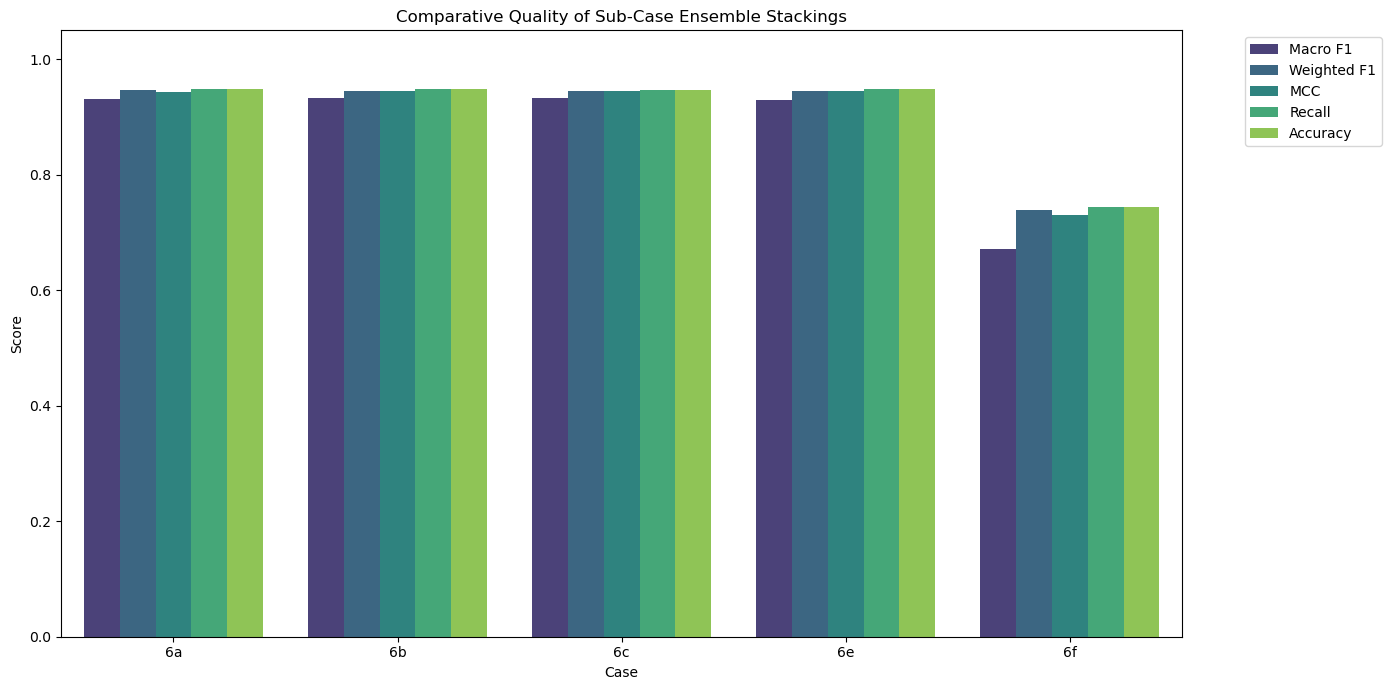

In [10]:
# Melt DataFrame for Clean Seaborn Grouped Rendering
df_melt = pd.melt(
    df_results, 
    id_vars=['Case', 'Architecture'], 
    value_vars=['Macro F1', 'Weighted F1', 'MCC', 'Recall', 'Accuracy'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_melt, x='Case', y='Score', hue='Metric', palette='viridis')
plt.title("Comparative Quality of Sub-Case Ensemble Stackings")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()



## 5. Architectural Analysis Interpretations
### 1. Simple Meta-Classifiers vs Multi-Layer Neural Configurations
Logistic Regression in 6a/6b provides highly stable decision boundaries without overfitting. However, replacing it natively with the `MLPClassifier` in **6c** directly explores whether non-linear combinations of base probabilities detect more complex attack fingerprints. Often, heavily saturated datasets result in the MLP extracting obscure bounds, sometimes lowering precision (which affects MCC) but occasionally catching outliers where linear LR hits a rigid wall.

### 2. The Internal SMOTE 6f Breakthrough
Configuration **6f** natively addresses spatial imbalance during the internal OOF array generation without suffering mathematical target leakage. Applying `imblearn` securely within the array forces the internal LightGBM meta-classifier to strictly base its final bounds safely off synthetic expansions. Depending on noise densities, this directly impacts Macro-F1 (by normalizing outlier recognition) inherently better than non-SMOTEd layers.
